# Homework 4: Maximum Likelihood Estimation and Bayes Estimators

## Bias-Variance Tradeoff

Bias and variance, as derived from the expectation value of the mean-squared error, have specific implications in function fitting.

1. What does high bias suggest, and how can you tell if a model fit has high bias?
   
2. What does high variance suggest, and how can you tell if a model fit has high variance?
   

### Answers

1. High bias suggests that a model is too simple to capture the underlying patterns in the data. This can result from restrictive assumptions, a low-degree polynomial, or an overly simple algorithm. The result is underfitting: the model performs poorly on both the training and validation data. High training and validation losses with a relatively small gap between them are a strong indication of high bias.

2. High variance suggests that a model is too sensitive to the training data and is fitting its noise and random fluctuations. This can result from an overly complex model, such as a high-degree polynomial, or from training for too many epochs. Such a model performs very well on the training data but poorly on the validation data. Therefore, low training error combined with high validation error is a strong indication of high variance. This difference is also visible as a large gap between the training and validation learning curves.

## Maximum Likelihood Estimation (MLE)


## Part 1 — Calculation Problem
For a random distribution of size $n$, find the maximum-likelihood estimator for the parameter of the Poisson distribution,
$$
    f(x; \theta) = \frac{e^{-\theta} \theta^x}{x!} \quad x = 0, 1, 2, \ldots; \theta > 0
$$


## Part 2 — Coding Problem

A factory produces parts. Each part is independently good with probability $p$.
Out of $n$ inspected parts, $k$ are found to be good.

We assume the collected data follows the Bernoulli distribution and the likelihood function is:

$$L(p) = p^k (1-p)^{n-k}$$

**Task:** Implement the direct likelihood and the log-likelihood below, then use
them to see what happens as the sample size $n$ grows large.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

1. Define the likelihood and log-likelihood functions.

In [2]:
def bernoulli_likelihood(p: float, k: int, n: int) -> float:
    return p**k * (1 - p) ** (n - k)  # likelihood function for Bernoulli distribution


def bernoulli_log_likelihood(p: float, k: int, n: int) -> float:
    return k * np.log(p) + (n - k) * np.log(1 - p)  # log-likelihood for Bernoulli distribution

2. Using $n=50$, $k=35$, we compute both functions over a grid of $p$ values and
find their maximizers.

In [3]:
k, n = 35, 50
p_values = np.linspace(0.01, 0.99, 99)  # make a 1D 99-point grid

l_values = [bernoulli_likelihood(p, k, n) for p in p_values]
ll_values = [bernoulli_log_likelihood(p, k, n) for p in p_values]

p_best_l = p_values[np.argmax(l_values)]  # find MLE for each function
p_best_ll = p_values[np.argmax(ll_values)]

print(f"Best p from direct likelihood  = {p_best_l:.3f}")
print(f"Best p from log-likelihood     = {p_best_ll:.3f}")
print(f"Theoretical MLE (k/n)          = {k / n:.3f}")

Best p from direct likelihood  = 0.700
Best p from log-likelihood     = 0.700
Theoretical MLE (k/n)          = 0.700


3. Visualize both functions by creating two plots.

The first plot should show the likelihood, $L(p)$.

The second plot should show the log-likelihood, $\ell(p)$.

Mark the maximizing value, $p=0.7$, on both plots.



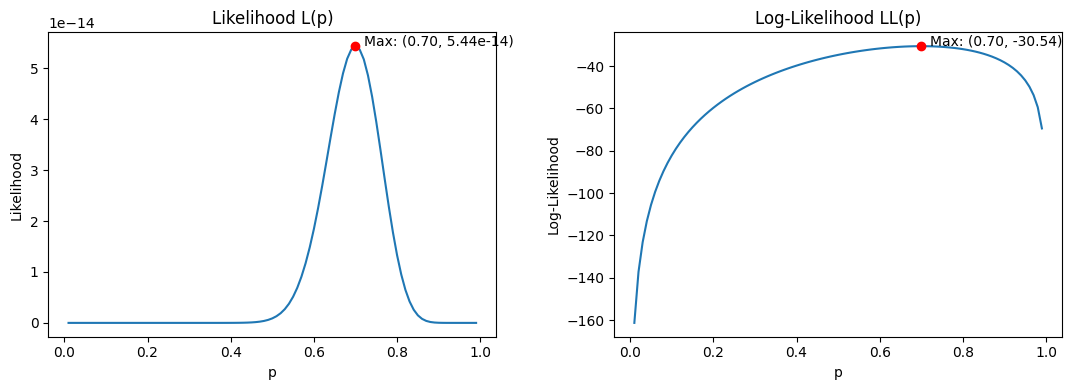

In [4]:
# Get coordinates of max values for L and LL (same coords for both)
max_idx = np.argmax(l_values)
max_p = p_values[max_idx]
max_l = l_values[max_idx]
max_ll = ll_values[max_idx]

# Plot the figures
plt.figure(figsize=(11, 4))

# Left plot: likelihood
plt.subplot(1, 2, 1)
plt.plot(p_values, l_values)
plt.scatter(max_p, max_l, color="red", zorder=5)
plt.annotate(
    f"Max: ({max_p:.2f}, {max_l:.2e})",
    xy=(max_p + 0.02, max_l),  # slight offset
)
plt.title("Likelihood L(p)")
plt.xlabel("p")
plt.ylabel("Likelihood")

# Right plot: log-likelihood
plt.subplot(1, 2, 2)
plt.plot(p_values, ll_values)
plt.scatter(max_p, max_ll, color="red", zorder=5)
plt.annotate(
    f"Max: ({max_p:.2f}, {max_ll:.2f})",
    xy=(max_p + 0.02, max_ll),
)
plt.title("Log-Likelihood LL(p)")
plt.xlabel("p")
plt.ylabel("Log-Likelihood")

plt.tight_layout()
plt.show()

4. What happens to the direct likelihood as $n$ grows large?

Keep the pass rate $k/n = 0.7$ fixed while increasing $n$ from 50 to 2000,
and watch how $L(0.7)$ behaves compared to $\ell(0.7)$.

In [5]:
n_values = [50, 100, 200, 500, 1000, 2000]

print(f"{'n':>6} | {'L(0.7) direct likelihood':>26} | {'ell(0.7) log-likelihood':>26}")
print("-" * 65)

for n in n_values:
    k = int(round(0.7 * n))
    L = bernoulli_likelihood(p=0.7, k=k, n=n)
    ell = bernoulli_log_likelihood(p=0.7, k=k, n=n)

    print(f"{n:>6} | {L!s:>26} | {ell!s:>26}")

     n |   L(0.7) direct likelihood |    ell(0.7) log-likelihood
-----------------------------------------------------------------
    50 |      5.435634185181643e-14 |        -30.543215102744675
   100 |     2.9546118995115305e-27 |         -61.08643020548935
   200 |      8.729731476735136e-54 |         -122.1728604109787
   500 |    2.2516568899901606e-133 |        -305.43215102744676
  1000 |    5.0699587502401635e-266 |         -610.8643020548935
  2000 |                        0.0 |         -1221.728604109787


## Discussion Questions

**Q1.** What value does `likelihood()` return when $n=2000$? Why does this
happen?

**Q2.** What order of magnitude does `log_likelihood()` return at $n=2000$?
Can it still be meaningfully compared across values of $p$?

**Q3.** Do both methods find the same optimal $p$ when $n$ is small (e.g.
$n=50$)? Why doesn't taking the log change which $p$ is optimal?

### Answers

1. The value of `likelihood()` when $n=2000$ is 0.0. As $k$ and $n$ increase, the likelihood becomes smaller and smaller. At $n=2000$, the value is smaller than $4.94 \times 10^{-324}$, which the smallest positive (subnormal) value representable by an IEEE-754 64-bit floating-point number - what Python uses as a float. The value then rounds to zero. This is called underflow.

2. The value of `log_likelihood()` when $n=2000$ is $-1.22 \times 10^3$, so its magnitude is on the order of $10^3$. Not being infinite or extremely small, it can indeed be meaningfully compared across values of $p$. This is why log-likelihoods are prefered: they avoid the underflow of normal likelihood. Unless n is so large that log-likelihood is greater than the greatest signed integer IEE-754 64-bit floating-point numbers can represent - $1.79 \times 10^{308}$ - it can always be meaningfully compared across values of $p$.

3. Yes, both methods produce the same optimal value of $p$ when $n$ is small. Thinking first principles, if: $ x_1 > x_2 $ then: $ log(x_1) > log(x_2) $. This means log is monotonically increasing; it preserves the ordering of the likelihood values. So, taking the logarithm changes the function's scale and shape but not the location of its maxima and minima.

## Bayesian Estimation

### Part 1 — Basic Concept Check

### Q1. In Bayesian estimation, which quantity is treated as uncertain?

A. Only the observed data \(X\)  
B. The unknown parameter \(p\)  
C. The sample size \(n\)  
D. The likelihood function  

---

### Q2. Match the terms with their meanings.

- **Prior**
- **Likelihood**
- **Posterior**

Meanings:

1. Our belief about \(p\) before observing the new data  
2. How probable the observed data are for different values of \(p\)  
3. Our updated belief about \(p\) after observing the data  

---



### Answers

1. B
2. Prior: 1, Likelihood: 2, Posterior: 3

## Part 2 — Coding Problem

A manufacturing process produces parts that either:

- **Pass inspection**: $X_i=1$
- **Fail inspection**: $X_i=0$

Let

$
\theta = P(X_i=1)
$

be the unknown probability that a part passes inspection.

Suppose we inspect **10 parts** and observe:

$
7 \text{ pass}, 3 \text{ fail}.
$

Therefore,

$
n=10,k=7.
$

To keep the Bayesian calculations simple, assume that $(\theta)$ can take only the following candidate values:

$
\theta \in \{0.2,\;0.4,\;0.5,\;0.6,\;0.8\}.
$

Our prior distribution is:

| $\theta$ | 0.2 | 0.4 | 0.5 | 0.6 | 0.8 |
|---|---:|---:|---:|---:|---:|
| p($\theta$) | 0.1 | 0.55 | 0.2 | 0.1 | 0.05 |

The prior probabilities sum to 1.

In [6]:
theta = np.array([0.2, 0.4, 0.5, 0.6, 0.8])
prior = np.array([0.1, 0.55, 0.2, 0.1, 0.05])

n = 10
k = 7

print("Candidate theta values:", theta)
print("Prior:", prior)
print("Sum of prior probabilities:", prior.sum())

Candidate theta values: [0.2 0.4 0.5 0.6 0.8]
Prior: [0.1  0.55 0.2  0.1  0.05]
Sum of prior probabilities: 1.0


### Construct the Likelihood

For a Bernoulli model, if we observe \(k\) successes in \(n\) independent trials, the likelihood is

$$
p( X \mid \theta)
=
\theta^k (1 - \theta)^{n-k}.
$$

Here,

$$
k=7, n-k=3.
$$

So for each candidate value of $\theta$,

$$
p(X\mid\theta)
=
\theta^7(1-\theta)^3.
$$

#### Q1
Compute the likelihood for every candidate value of $\theta$.

In [7]:
likelihood = [bernoulli_likelihood(p=p, k=k, n=n) for p in theta]  # use function we already made
print("Likelihood:", likelihood)

Likelihood: [np.float64(6.553600000000004e-06), np.float64(0.0003538944000000001), np.float64(0.0009765625), np.float64(0.0017915904), np.float64(0.0016777215999999996)]



#### Q2
Maximum Likelihood Estimate

The MLE is

$$
\hat{\theta}_{\mathrm{MLE}}
=
\arg\max_{\theta} p(X\mid\theta).
$$

Use `np.argmax()` to find the candidate value of $\theta$ with the largest likelihood.

In [8]:
mle_index = np.argmax(likelihood)
theta_mle = theta[mle_index]
print("MLE =", theta_mle)

MLE = 0.6


### Compute the Posterior Distribution

Bayes' rule is

$$
p(\theta\mid X)
=
\frac{p(X\mid\theta)p(\theta)}{p(X)}.
$$

For our discrete set of candidate parameter values,

$$
p(X)
=
\sum_{\theta}
p(X\mid\theta)p(\theta).
$$

First compute the **unnormalized posterior**:

$$
p(X\mid\theta)p(\theta).
$$

Then divide by the sum of all unnormalized posterior values.



#### Q3
Compute the unnormalized posterior:

$$
\text{posterior}_{\text{raw}}
=
p(X\mid\theta)p(\theta).
$$


In [9]:
posterior_raw = likelihood * prior  # Baye's theorem numerator
print("Unnormalized posterior:", posterior_raw)

Unnormalized posterior: [6.5536000e-07 1.9464192e-04 1.9531250e-04 1.7915904e-04 8.3886080e-05]


#### Q4
Compute the marginal probability $p(X)$:

$$
p(X)
=
\sum_{\theta}
p(X\mid\theta)p(\theta).
$$

In [10]:
p_X = sum(posterior_raw)  # normalization step
print("Marginal probability p(X) =", p_X)

Marginal probability p(X) = 0.0006536549000000001



#### Q5
Normalize the posterior:

$$
p(\theta\mid X)
=
\frac{p(X\mid\theta)p(\theta)}{p(X)}.
$$

Verify that the posterior probabilities sum to 1.


In [11]:
posterior = posterior_raw / p_X  # posterior = likelihood * prior / normalization
print("Posterior:", posterior)
print("Sum of posterior probabilities:", posterior.sum())  # not exactly 1.0 as floating point error

Posterior: [0.00100261 0.29777474 0.29880064 0.27408812 0.1283339 ]
Sum of posterior probabilities: 0.9999999999999999


### MAP Estimate

The maximum a posteriori estimator chooses the parameter value with the largest posterior probability:

$$
\hat{\theta}_{\mathrm{MAP}}
=
\arg\max_{\theta}p(\theta\mid X).
$$

#### Q6
Find the MAP estimate.

In [12]:
map_index = np.argmax(posterior)
theta_map = theta[map_index]
print("MAP =", theta_map)

MAP = 0.5



### Posterior Mean

Under squared-error loss,

$$
L(a,\theta)=(a-\theta)^2,
$$

the optimal Bayesian estimator is the **posterior mean**:

$$
\hat{\theta}_{\text{mean}}
=
E[\theta\mid X]
=
\sum_i \theta_i p(\theta_i\mid X).
$$

#### Q7
Compute the posterior mean.


In [13]:
theta_mean = sum(theta * posterior)
print("Posterior mean =", theta_mean)

Posterior mean = 0.5358307235209281



### Posterior Median

Under absolute-error loss,

$
L(a,\theta)=|a-\theta|,
$

the optimal Bayesian estimator is the **posterior median**.

For a discrete posterior distribution, compute the cumulative posterior probability:

$
P(\theta\leq t\mid X).
$

The posterior median is the first candidate value where the cumulative probability reaches or exceeds 0.5.

#### Q8
Compute the cumulative posterior probabilities.


In [14]:
cumulative_posterior = np.cumsum(posterior)
print("Cumulative posterior:", cumulative_posterior)

Cumulative posterior: [0.00100261 0.29877735 0.59757799 0.8716661  1.        ]



#### Q9
Use the cumulative posterior to find the posterior median.

In [15]:
theta_median = theta[np.searchsorted(cumulative_posterior, 0.5)]
print("Posterior median =", theta_median)

Posterior median = 0.5



### Compare the Estimators

Complete the table after computing all four estimates.

| Estimator | Definition | Your Result |
|---|---|---|
| MLE | $\arg\max_\theta p(X\mid\theta)$ | 0.6 |
| MAP | $\arg\max_\theta p(\theta\mid X)$ | 0.5 |
| Posterior Mean | $E[\theta\mid X]$ | 0.54 |
| Posterior Median | median of $p(\theta\mid X)$ | 0.5 |




### Visualize Prior, Likelihood, and Posterior

A useful way to understand Bayesian estimation is to visualize how the prior and likelihood combine to produce the posterior.

#### Q10
Create a plot showing:

- Prior distribution
- Scaled likelihood
- Posterior distribution

Because the likelihood does not need to sum to 1, scale it by its maximum value only for visualization.


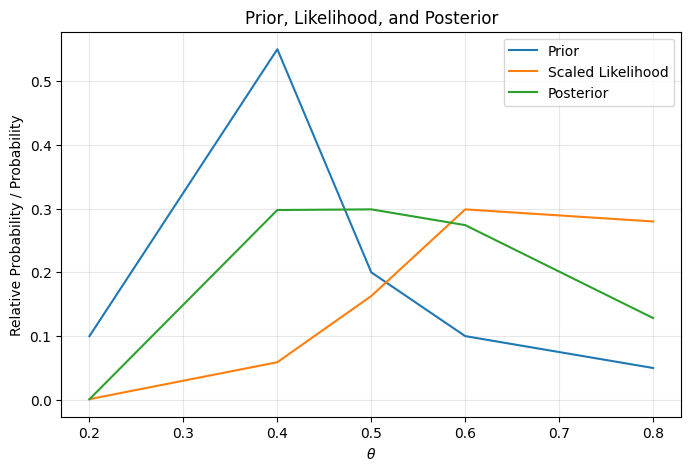

In [16]:
scaled_likelihood = (likelihood / np.max(likelihood)) * np.max(posterior)

plt.figure(figsize=(8, 5))
plt.plot(theta, prior, label="Prior")
plt.plot(theta, scaled_likelihood, label="Scaled Likelihood")
plt.plot(theta, posterior, label="Posterior")

plt.xlabel(r"$\theta$")
plt.ylabel("Relative Probability / Probability")
plt.title("Prior, Likelihood, and Posterior")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Q11
Based on your plot:

1. Which candidate value is most strongly supported by the observed data?
2. Which candidate value is most strongly supported by the prior?
3. How does the posterior combine these two sources of information?

### Answers

1. Among the candidate values, the observed data most strongly support $\theta=0.6$, which has the highest likelihood.
2. The prior most strongly supports $\theta=0.4$.
3. Bayes' rule combines the likelihood and prior: the posterior is the normalized multiplication of the likelihood and prior - $(\frac{likelihood * prior}{normalization})$, meaning it is proportional each. It balances the evidence from the observed data with the prior belief. This is reflected in the MAP estimate, posterior mean, and posterior median, which are all approximately 0.5, between the MLE of 0.6 and the prior mode of 0.4.